In [ ]:
import numpy as np
import pandas as pd
import nltk
import string
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [ ]:
from google.colab import files
upload = files.upload()

Saving IDTATextPreprocessing.csv to IDTATextPreprocessing.csv


In [ ]:
#text preprocessing
reviews = pd.read_csv("IDTATextPreprocessing.csv")

In [ ]:
reviews.head()

,Unnamed: 0,Review,Sentiment
0,0,way plug u unless go converter,0
1,1,good case excellent value,1
2,2,great jawbone,1
3,3,tie charger conversation last minutesmajor pro...,0
4,4,mic great,1


In [ ]:
reviews.shape

(1000, 3)

In [ ]:
#split the dataset

#train dataset by splitting the data
train_reviews = reviews.Review[:700]
train_sentiments = reviews.Sentiment[:700]

#test dataset
test_reviews = reviews.Review[700:]
test_sentiments = reviews.Sentiment[700:]

print(train_reviews.shape,train_sentiments.shape)
print(test_reviews.shape,test_sentiments.shape)

(700,) (700,)
(300,) (300,)


In [ ]:
train_reviews[0]

'way plug u unless go converter'

In [ ]:
#Count vectorizer for bag of words
#cv=CountVectorizer(min_df=0,max_df=1,binary=False,ngram_range=(1,3))
cv=CountVectorizer()

#transformed train reviews
cv_train_reviews=cv.fit_transform(train_reviews)
#transformed test reviews
cv_test_reviews=cv.transform(test_reviews)

print('BOW_cv_train:',cv_train_reviews.shape)
print('BOW_cv_test:',cv_test_reviews.shape)

#vocab=cv.get_feature_names_out() #toget feature names

BOW_cv_train: (700, 1202)
BOW_cv_test: (300, 1202)


In [ ]:
print(cv_train_reviews[0])

  (0, 1152)	1
  (0, 785)	1
  (0, 1110)	1
  (0, 454)	1
  (0, 222)	1


In [ ]:
#Tfidf vectorizer
#tv=TfidfVectorizer(min_df=0,max_df=1,use_idf=True,ngram_range=(1,3))
tv=TfidfVectorizer()

#transformed train reviews
tv_train_reviews=tv.fit_transform(train_reviews)
#transformed test reviews
tv_test_reviews=tv.transform(test_reviews)
print('Tfidf_train:',tv_train_reviews.shape)
print('Tfidf_test:',tv_test_reviews.shape)

Tfidf_train: (700, 1202)
Tfidf_test: (300, 1202)


In [ ]:
print(tv_train_reviews[0])

  (0, 222)	0.5327017585343223
  (0, 454)	0.36650303281368973
  (0, 1110)	0.5012131132572704
  (0, 785)	0.3873365628648976
  (0, 1152)	0.4250413692333605


In [ ]:
print(train_sentiments)
print(test_sentiments)

0      0
1      1
2      1
3      0
4      1
      ..
695    0
696    1
697    0
698    1
699    1
Name: Sentiment, Length: 700, dtype: int64
700    0
701    1
702    1
703    1
704    0
      ..
995    0
996    0
997    0
998    0
999    0
Name: Sentiment, Length: 300, dtype: int64


DT_bow accuracy : 0.7233333333333334
DT_tfidf accuracy : 0.7266666666666667
[[115  41]
 [ 42 102]] 

              precision    recall  f1-score   support

    Positive       0.73      0.74      0.73       156
    Negative       0.71      0.71      0.71       144

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300

[[122  34]
 [ 48  96]] 

              precision    recall  f1-score   support

    Positive       0.72      0.78      0.75       156
    Negative       0.74      0.67      0.70       144

    accuracy                           0.73       300
   macro avg       0.73      0.72      0.72       300
weighted avg       0.73      0.73      0.73       300

roc_auc_score for DT TFIDF:  0.7243589743589742
roc_auc_score for DT BoW:  0.7227564102564104


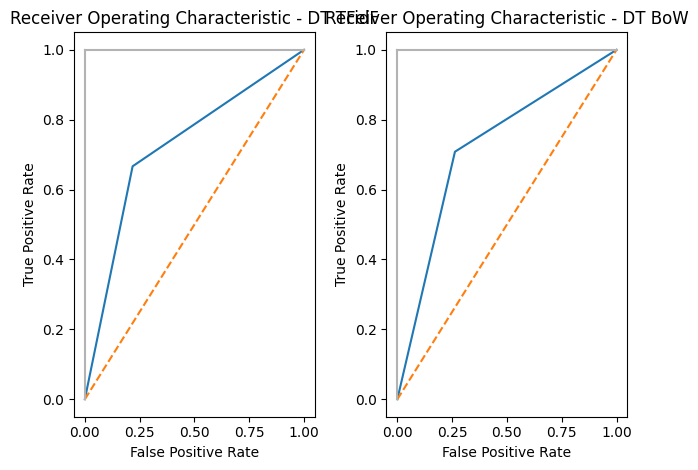

In [ ]:
############################################
###           Decision Tree              ###
############################################
#training the model
DT=DecisionTreeClassifier(criterion ='entropy', random_state= 0)

#Fitting the model for Bag of words
DT_bow=DT.fit(cv_train_reviews,train_sentiments)

#Fitting the model for tfidf features
DT_tfidf=DT.fit(tv_train_reviews,train_sentiments)

#Predicting the model for bag of words
DT_bow_predict=DT.predict(cv_test_reviews)

##Predicting the model for tfidf features
DT_tfidf_predict=DT.predict(tv_test_reviews)

#Accuracy score for bag of words
DT_bow_score=accuracy_score(test_sentiments,DT_bow_predict)
print("DT_bow accuracy :",DT_bow_score)

#Accuracy score for tfidf features
DT_tfidf_score=accuracy_score(test_sentiments,DT_tfidf_predict)
print("DT_tfidf accuracy :",DT_tfidf_score)

#Classification report for bag of words
DT_bow_report=classification_report(test_sentiments,DT_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,DT_bow_predict), '\n')
print(DT_bow_report)

#Classification report for tfidf features
DT_tfidf_report=classification_report(test_sentiments,DT_tfidf_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,DT_tfidf_predict), '\n')
print(DT_tfidf_report)

#AUC score and ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

FP, TP, threshold1 = roc_curve(test_sentiments, DT_tfidf_predict)
print('roc_auc_score for DT TFIDF: ', roc_auc_score(test_sentiments, DT_tfidf_predict))

FPbow, TPbow, threshold2 = roc_curve(test_sentiments, DT_bow_predict)
print('roc_auc_score for DT BoW: ', roc_auc_score(test_sentiments, DT_bow_predict))

import matplotlib.pyplot as plt

figsize=(20,20)

plt.subplot(1,2,1)
plt.title('Receiver Operating Characteristic - DT TFidF')
plt.plot(FP, TP)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')


plt.subplot(1,2,2)
plt.title('Receiver Operating Characteristic - DT BoW')
plt.plot(FPbow, TPbow)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

NB_bow accuracy : 0.8033333333333333
NB_tfidf accuracy : 0.8033333333333333
[[108  48]
 [ 11 133]] 

              precision    recall  f1-score   support

    Positive       0.91      0.69      0.79       156
    Negative       0.73      0.92      0.82       144

    accuracy                           0.80       300
   macro avg       0.82      0.81      0.80       300
weighted avg       0.82      0.80      0.80       300

[[115  41]
 [ 18 126]] 

              precision    recall  f1-score   support

    Positive       0.86      0.74      0.80       156
    Negative       0.75      0.88      0.81       144

    accuracy                           0.80       300
   macro avg       0.81      0.81      0.80       300
weighted avg       0.81      0.80      0.80       300

roc_auc_score for NB TFIDF:  0.8060897435897436
roc_auc_score for NB BoW:  0.8079594017094017


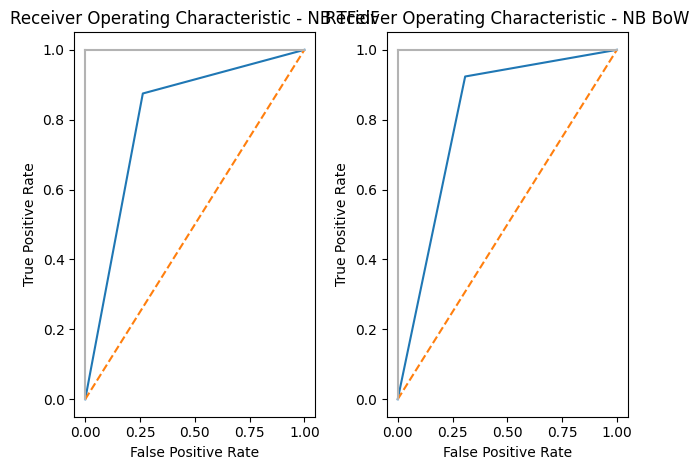

In [ ]:
############################################
###             Naive Bayes              ###
############################################

NB = MultinomialNB()

#Fitting the model for Bag of words
NB_bow = NB.fit(cv_train_reviews,train_sentiments)

#Fitting the model for tfidf features
NB_tfidf = NB.fit(tv_train_reviews,train_sentiments)

#Predicting the model for bag of words
NB_bow_predict = NB.predict(cv_test_reviews)

#Predicting the model for tfidf features
NB_tfidf_predict = NB.predict(tv_test_reviews)

#Accuracy score for bag of words
NB_bow_score=accuracy_score(test_sentiments,NB_bow_predict)
print("NB_bow accuracy :",NB_bow_score)

#Accuracy score for tfidf features
NB_tfidf_score=accuracy_score(test_sentiments,NB_tfidf_predict)
print("NB_tfidf accuracy :",NB_tfidf_score)

#Classification report for bag of words
NB_bow_report=classification_report(test_sentiments,NB_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,NB_bow_predict), '\n')
print(NB_bow_report)

#Classification report for tfidf features
NB_tfidf_report=classification_report(test_sentiments,NB_tfidf_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,NB_tfidf_predict), '\n')
print(NB_tfidf_report)

FP, TP, threshold3 = roc_curve(test_sentiments, NB_tfidf_predict)
print('roc_auc_score for NB TFIDF: ', roc_auc_score(test_sentiments, NB_tfidf_predict))

FPbow, TPbow, threshold4 = roc_curve(test_sentiments, NB_bow_predict)
print('roc_auc_score for NB BoW: ', roc_auc_score(test_sentiments, NB_bow_predict))

figsize=(20,20)

plt.subplot(1,2,1)
plt.title('Receiver Operating Characteristic - NB TFidF')
plt.plot(FP, TP)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')


plt.subplot(1,2,2)
plt.title('Receiver Operating Characteristic - NB BoW')
plt.plot(FPbow, TPbow)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

SVM_bow accuracy : 0.8033333333333333
SVM_tfidf accuracy : 0.7933333333333333
[[118  38]
 [ 21 123]] 

              precision    recall  f1-score   support

    Positive       0.85      0.76      0.80       156
    Negative       0.76      0.85      0.81       144

    accuracy                           0.80       300
   macro avg       0.81      0.81      0.80       300
weighted avg       0.81      0.80      0.80       300

[[126  30]
 [ 32 112]] 

              precision    recall  f1-score   support

    Positive       0.80      0.81      0.80       156
    Negative       0.79      0.78      0.78       144

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300

roc_auc_score for SVM TFIDF:  0.7927350427350428
roc_auc_score for SVM BoW:  0.8052884615384615


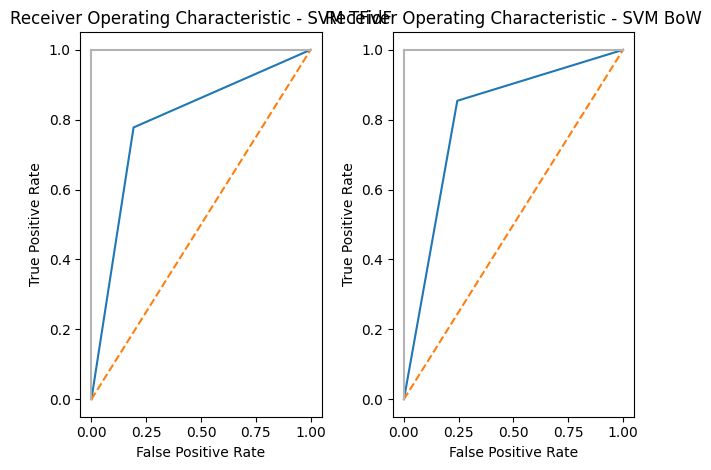

In [ ]:
############################################
###                  SVM                 ###
############################################
#linear SVM
SVM = SGDClassifier(loss='hinge',max_iter=500,random_state=42)

#Fitting the model for Bag of words
SVM_bow = SVM.fit(cv_train_reviews,train_sentiments)

#Fitting the model for tfidf features
SVM_tfidf = SVM.fit(tv_train_reviews,train_sentiments)

#Predicting the model for bag of words
SVM_bow_predict = SVM.predict(cv_test_reviews)

#Predicting the model for tfidf features
SVM_tfidf_predict = SVM.predict(tv_test_reviews)

#Accuracy score for bag of words
SVM_bow_score=accuracy_score(test_sentiments,SVM_bow_predict)
print("SVM_bow accuracy :",SVM_bow_score)

#Accuracy score for tfidf features
SVM_tfidf_score=accuracy_score(test_sentiments,SVM_tfidf_predict)
print("SVM_tfidf accuracy :",SVM_tfidf_score)

#Classification report for bag of words
SVM_bow_report=classification_report(test_sentiments,SVM_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,SVM_bow_predict), '\n')
print(SVM_bow_report)

#Classification report for tfidf features
SVM_tfidf_report=classification_report(test_sentiments,SVM_tfidf_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,SVM_tfidf_predict), '\n')
print(SVM_tfidf_report)

FP, TP, threshold5 = roc_curve(test_sentiments, SVM_tfidf_predict)
print('roc_auc_score for SVM TFIDF: ', roc_auc_score(test_sentiments, SVM_tfidf_predict))

FPbow, TPbow, threshold6 = roc_curve(test_sentiments, SVM_bow_predict)
print('roc_auc_score for SVM BoW: ', roc_auc_score(test_sentiments, SVM_bow_predict))

figsize=(20,20)

plt.subplot(1,2,1)
plt.title('Receiver Operating Characteristic - SVM TFidF')
plt.plot(FP, TP)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')


plt.subplot(1,2,2)
plt.title('Receiver Operating Characteristic - SVM BoW')
plt.plot(FPbow, TPbow)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

kNN_bow accuracy : 0.7033333333333334
kNN_tfidf accuracy : 0.78
[[ 78  78]
 [ 11 133]] 

              precision    recall  f1-score   support

    Positive       0.88      0.50      0.64       156
    Negative       0.63      0.92      0.75       144

    accuracy                           0.70       300
   macro avg       0.75      0.71      0.69       300
weighted avg       0.76      0.70      0.69       300

[[104  52]
 [ 14 130]] 

              precision    recall  f1-score   support

    Positive       0.88      0.67      0.76       156
    Negative       0.71      0.90      0.80       144

    accuracy                           0.78       300
   macro avg       0.80      0.78      0.78       300
weighted avg       0.80      0.78      0.78       300

roc_auc_score for kNN TFIDF:  0.7847222222222223
roc_auc_score for kNN BoW:  0.7118055555555556


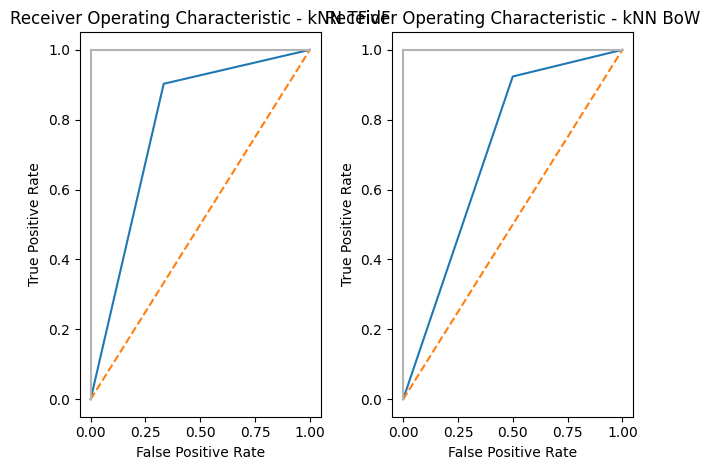

In [ ]:
############################################
###                  k-NN                ###
############################################

kNN = KNeighborsClassifier(n_neighbors=7)

#Fitting the model for Bag of words
kNN_bow = kNN.fit(cv_train_reviews,train_sentiments)

#Fitting the model for tfidf features
kNN_tfidf = kNN.fit(tv_train_reviews,train_sentiments)

#Predicting the model for bag of words
kNN_bow_predict = kNN.predict(cv_test_reviews)

#Predicting the model for tfidf features
kNN_tfidf_predict = kNN.predict(tv_test_reviews)

#Accuracy score for bag of words
kNN_bow_score=accuracy_score(test_sentiments,kNN_bow_predict)
print("kNN_bow accuracy :",kNN_bow_score)

#Accuracy score for tfidf features
kNN_tfidf_score=accuracy_score(test_sentiments,kNN_tfidf_predict)
print("kNN_tfidf accuracy :",kNN_tfidf_score)

#Classification report for bag of words
kNN_bow_report=classification_report(test_sentiments,kNN_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,kNN_bow_predict), '\n')
print(kNN_bow_report)

#Classification report for tfidf features
kNN_tfidf_report=classification_report(test_sentiments,kNN_tfidf_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,kNN_tfidf_predict), '\n')
print(kNN_tfidf_report)

FP, TP, threshold7 = roc_curve(test_sentiments, kNN_tfidf_predict)
print('roc_auc_score for kNN TFIDF: ', roc_auc_score(test_sentiments, kNN_tfidf_predict))

FPbow, TPbow, threshold8 = roc_curve(test_sentiments, kNN_bow_predict)
print('roc_auc_score for kNN BoW: ', roc_auc_score(test_sentiments, kNN_bow_predict))

figsize=(20,20)

plt.subplot(1,2,1)
plt.title('Receiver Operating Characteristic - kNN TFidF')
plt.plot(FP, TP)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')


plt.subplot(1,2,2)
plt.title('Receiver Operating Characteristic - kNN BoW')
plt.plot(FPbow, TPbow)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

MLP_bow accuracy : 0.7933333333333333
MLP_tfidf accuracy : 0.78
[[120  36]
 [ 26 118]] 

              precision    recall  f1-score   support

    Positive       0.82      0.77      0.79       156
    Negative       0.77      0.82      0.79       144

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.80      0.79      0.79       300

[[124  32]
 [ 34 110]] 

              precision    recall  f1-score   support

    Positive       0.78      0.79      0.79       156
    Negative       0.77      0.76      0.77       144

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300

roc_auc_score for MLP TFIDF:  0.7793803418803419
roc_auc_score for MLP BoW:  0.7943376068376068


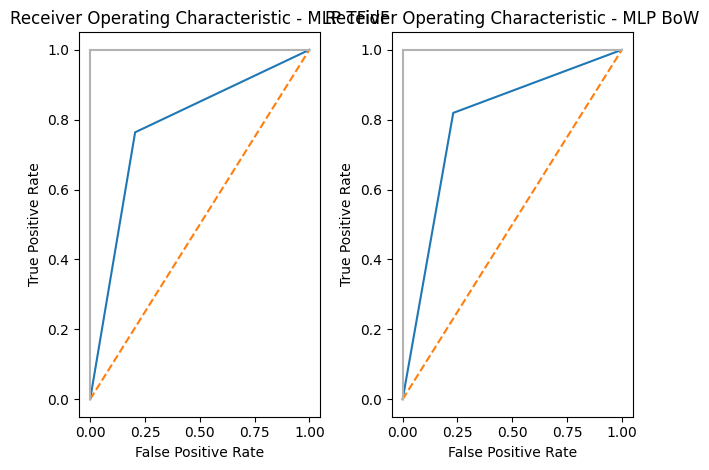

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

MLP = MLPClassifier(random_state=2)

#Fitting the model for Bag of words
MLP_bow = MLP.fit(cv_train_reviews,train_sentiments)

#Fitting the model for tfidf features
MLP_tfidf = MLP.fit(tv_train_reviews,train_sentiments)

#Predicting the model for bag of words
MLP_bow_predict = MLP.predict(cv_test_reviews)

#Predicting the model for tfidf features
MLP_tfidf_predict = MLP.predict(tv_test_reviews)

#Accuracy score for bag of words
MLP_bow_score=accuracy_score(test_sentiments,MLP_bow_predict)
print("MLP_bow accuracy :",MLP_bow_score)

#Accuracy score for tfidf features
MLP_tfidf_score=accuracy_score(test_sentiments,MLP_tfidf_predict)
print("MLP_tfidf accuracy :",MLP_tfidf_score)

#Classification report for bag of words
MLP_bow_report=classification_report(test_sentiments,MLP_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,MLP_bow_predict), '\n')
print(MLP_bow_report)

#Classification report for tfidf features
MLP_tfidf_report=classification_report(test_sentiments,MLP_tfidf_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,MLP_tfidf_predict), '\n')
print(MLP_tfidf_report)

FP, TP, threshold9 = roc_curve(test_sentiments, MLP_tfidf_predict)
print('roc_auc_score for MLP TFIDF: ', roc_auc_score(test_sentiments, MLP_tfidf_predict))

FPbow, TPbow, threshold10 = roc_curve(test_sentiments, MLP_bow_predict)
print('roc_auc_score for MLP BoW: ', roc_auc_score(test_sentiments, MLP_bow_predict))

figsize=(10,5)

plt.subplot(1,2,1)
plt.title('Receiver Operating Characteristic - MLP TFidF')
plt.plot(FP, TP)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')


plt.subplot(1,2,2)
plt.title('Receiver Operating Characteristic - MLP BoW')
plt.plot(FPbow, TPbow)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.tight_layout()
plt.show()